Installing and importing all the requirments

In [1]:
%pip install xarray rasterio fiona geopandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


d:\python\geog-312\.venv\Scripts\python.exe: No module named pip


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

Load Datasets

In [7]:

ds = xr.open_dataset(r"D:\python\Xarrey\downloaded data\climate data india\data_stream-moda_stepType-avgad.nc")

print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:     (valid_time: 44, latitude: 117, longitude: 117)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 352B 2015-06-01T06:00:00 ... 2025...
    expver      (valid_time) <U4 704B ...
  * latitude    (latitude) float64 936B 37.0 36.75 36.5 36.25 ... 8.5 8.25 8.0
  * longitude   (longitude) float64 936B 68.0 68.25 68.5 ... 96.5 96.75 97.0
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-03T13:51 GRIB to CDM+CF via cfgrib-0.9.1...


Checking Shape and other propertiess

In [6]:
tp =ds["tp"]

print("Shape: ",tp.shape)
print("Dims: ", tp.dims)
print("Time values: ", tp.valid_time.values)

Shape:  (44, 117, 117)
Dims:  ('valid_time', 'latitude', 'longitude')
Time values:  ['2015-06-01T06:00:00.000000000' '2015-07-01T06:00:00.000000000'
 '2015-08-01T06:00:00.000000000' '2015-09-01T06:00:00.000000000'
 '2016-06-01T06:00:00.000000000' '2016-07-01T06:00:00.000000000'
 '2016-08-01T06:00:00.000000000' '2016-09-01T06:00:00.000000000'
 '2017-06-01T06:00:00.000000000' '2017-07-01T06:00:00.000000000'
 '2017-08-01T06:00:00.000000000' '2017-09-01T06:00:00.000000000'
 '2018-06-01T06:00:00.000000000' '2018-07-01T06:00:00.000000000'
 '2018-08-01T06:00:00.000000000' '2018-09-01T06:00:00.000000000'
 '2019-06-01T06:00:00.000000000' '2019-07-01T06:00:00.000000000'
 '2019-08-01T06:00:00.000000000' '2019-09-01T06:00:00.000000000'
 '2020-06-01T06:00:00.000000000' '2020-07-01T06:00:00.000000000'
 '2020-08-01T06:00:00.000000000' '2020-09-01T06:00:00.000000000'
 '2021-06-01T06:00:00.000000000' '2021-07-01T06:00:00.000000000'
 '2021-08-01T06:00:00.000000000' '2021-09-01T06:00:00.000000000'
 '2022

Data Cleaning & Analysis:

In [17]:
#Converting data into mm
tp_mm = tp*1000
tp_mm.name = "tp_mm"

#Calculate average rainfall across India for each month
india_rain = tp_mm.mean(dim=["latitude", "longitude"])

#Find the wettest month
wettest_value = india_rain.max()
wettest_month = india_rain.idxmax(dim="valid_time")

print("Wettest rainfall: ", wettest_value.values,"mm")
print("wettest_month: ", wettest_month.values)

#Calculate yearly total rainfall 
yearly_rain = india_rain.groupby("valid_time.year").sum()

print("Shape: ",yearly_rain.shape)
print(yearly_rain)

# Fix rainfall values
yearly_rain_fixed = yearly_rain * 30 * 4  # 4 months × 30 days
print(yearly_rain_fixed.values)

Wettest rainfall:  9.678322 mm
wettest_month:  2024-07-01T06:00:00.000000000
Shape:  (11,)
<xarray.DataArray 'tp_mm' (year: 11)> Size: 44B
array([26.842136, 28.68761 , 29.381819, 27.444834, 31.307386, 31.341236,
       27.973942, 28.708553, 27.437042, 31.266342, 29.245096],
      dtype=float32)
Coordinates:
  * year     (year) int64 88B 2015 2016 2017 2018 2019 ... 2022 2023 2024 2025
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      13689
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
   

Plotting

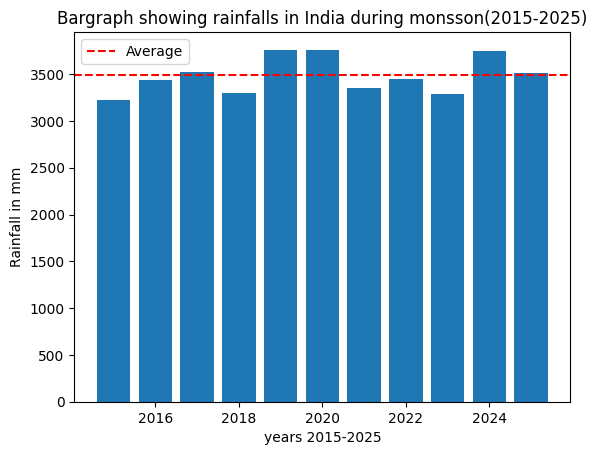

<Figure size 640x480 with 0 Axes>

In [28]:
import matplotlib.pyplot as plt
plt.figure()
plt.bar(yearly_rain_fixed.year,yearly_rain_fixed)
plt.title("Bargraph showing rainfalls in India during monsson(2015-2025)")
plt.xlabel("years 2015-2025")
plt.ylabel("Rainfall in mm")
# Add a horizontal line showing average rainfall
plt.axhline(y=yearly_rain_fixed.values.mean(), 
            color='red', 
            linestyle='--', 
            label='Average')

# Add legend
plt.legend()
plt.show()

plt.savefig("india_monsoon_rainfall.png", dpi=300, bbox_inches="tight")
